# Experiment 1 — headline benchmark (LGD)

5-fold CV on the 7 LGD datasets (loss-given-default regression on [0, 1]). For **R²** and **RMSE**: matrix (best column left), per-method bar (value above; **fold-level** std error bars), box plot. Then **compute time**, the **per-dataset rank (R²)**, the **HPO effect on R²**, and **performance-vs-compute**. Foundation-model names are red. Figures → `figures/experiment1/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/lgd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\lgd


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode=None)
print(f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

25 methods x 7 datasets


## R²

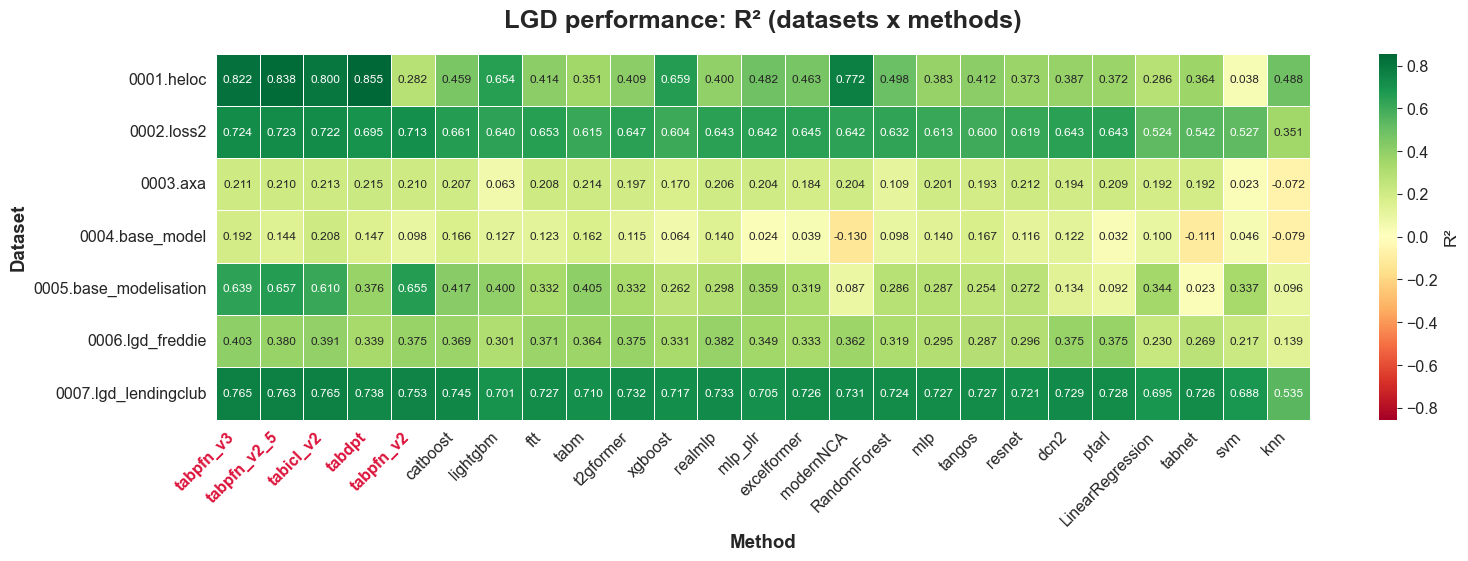

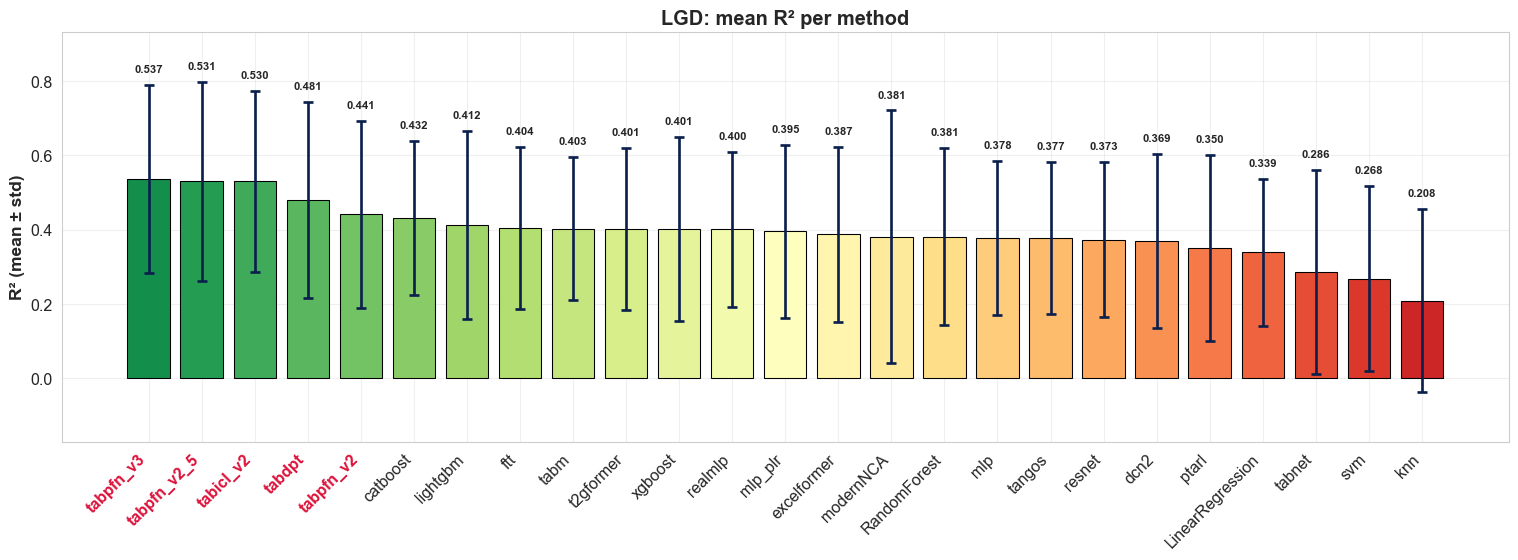

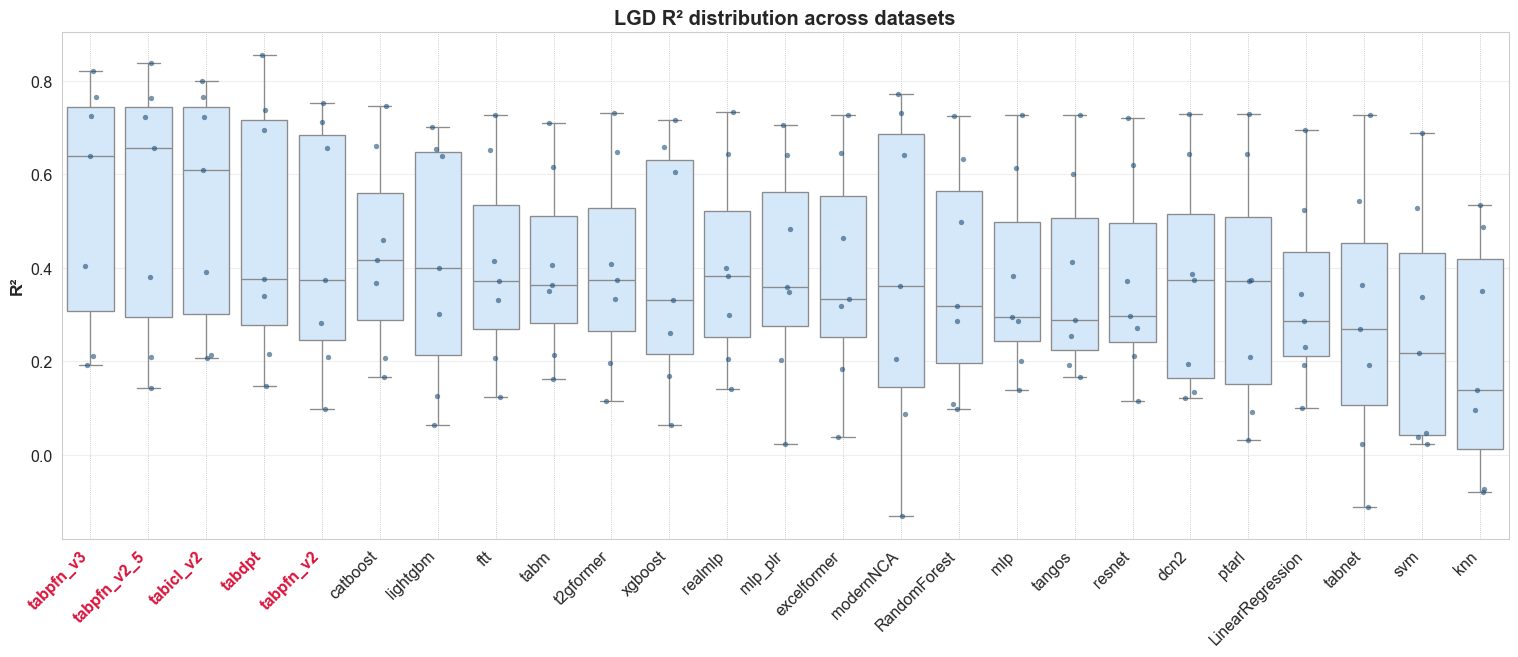

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_r2.pdf')

In [3]:
performance_heatmap(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)

## RMSE (lower is better)

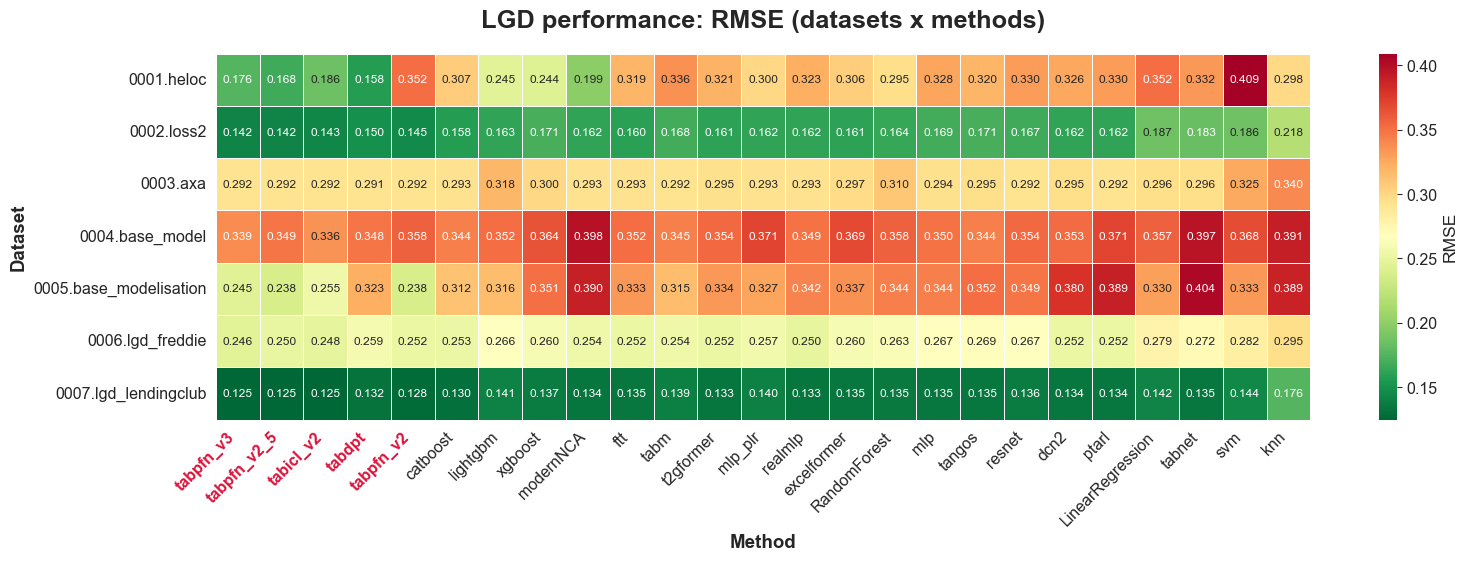

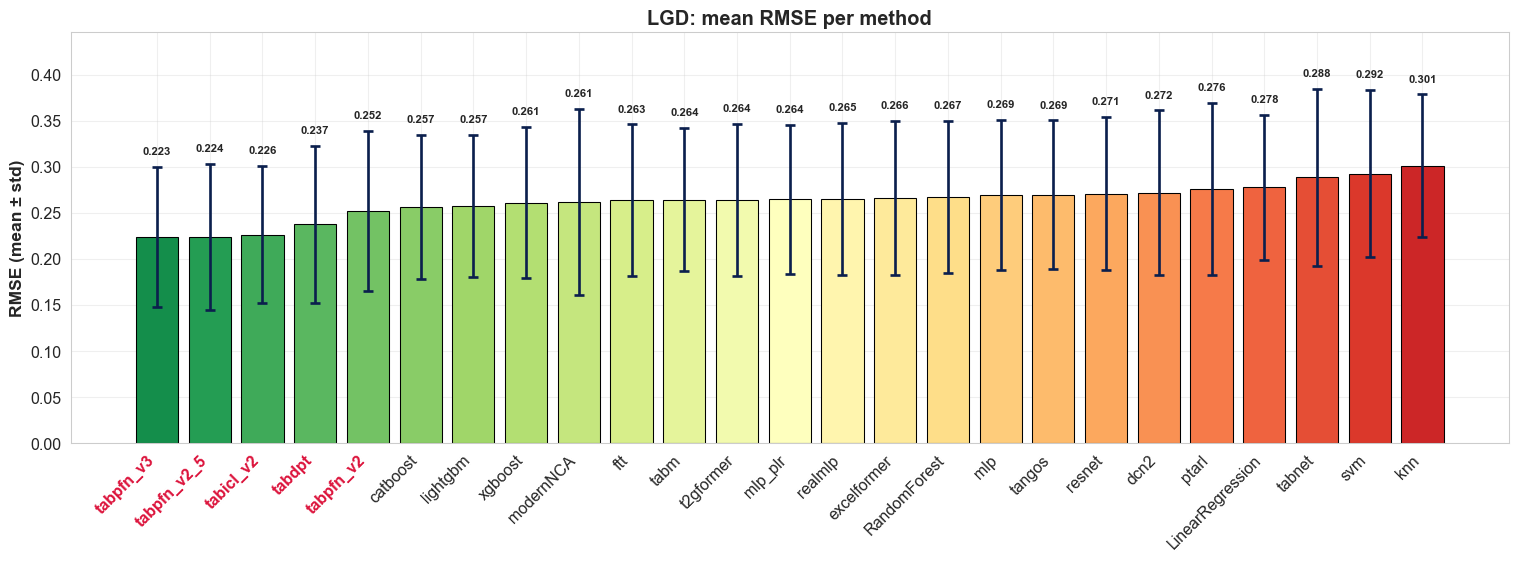

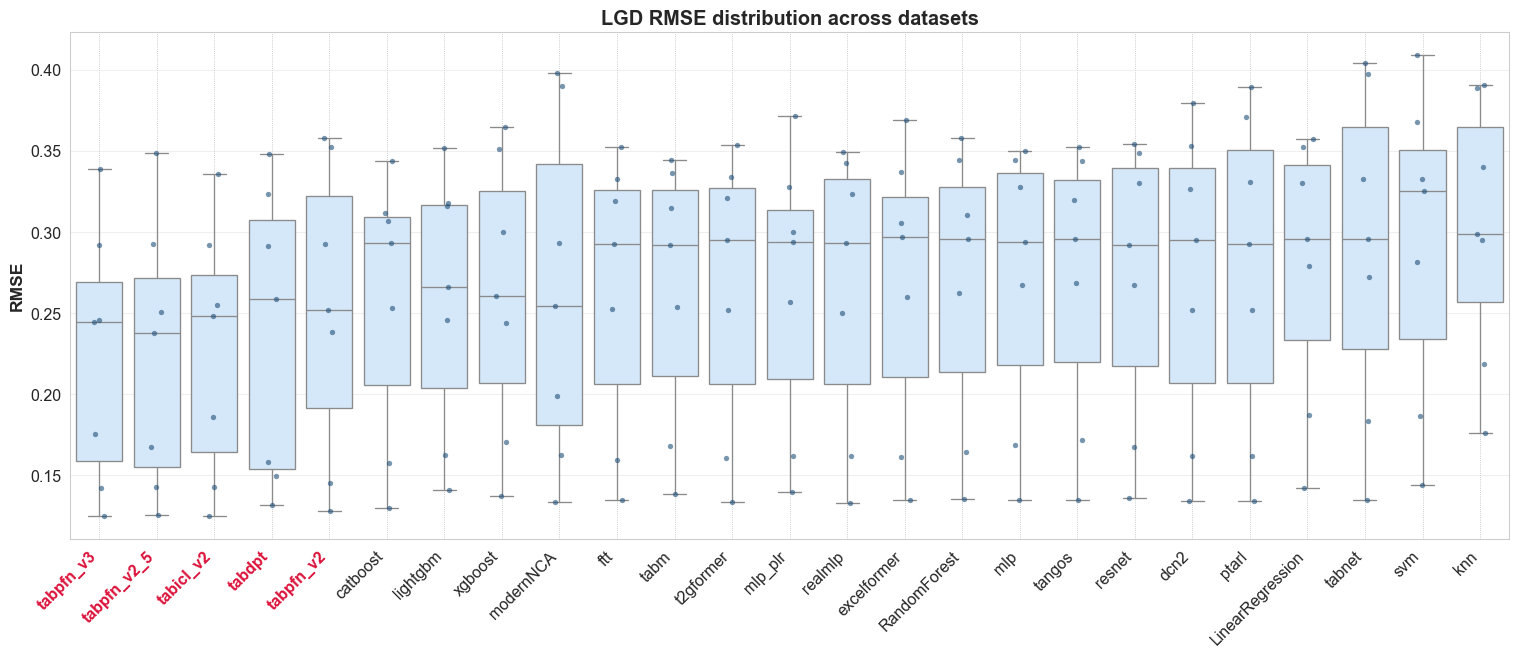

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_rmse.pdf')

In [4]:
performance_heatmap(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_bars(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_boxplots(df, 'RMSE', task_name='LGD', higher_is_better=False, out_dir=FIGURES_DIR)

## Compute time (fit + predict, seconds; log scale)

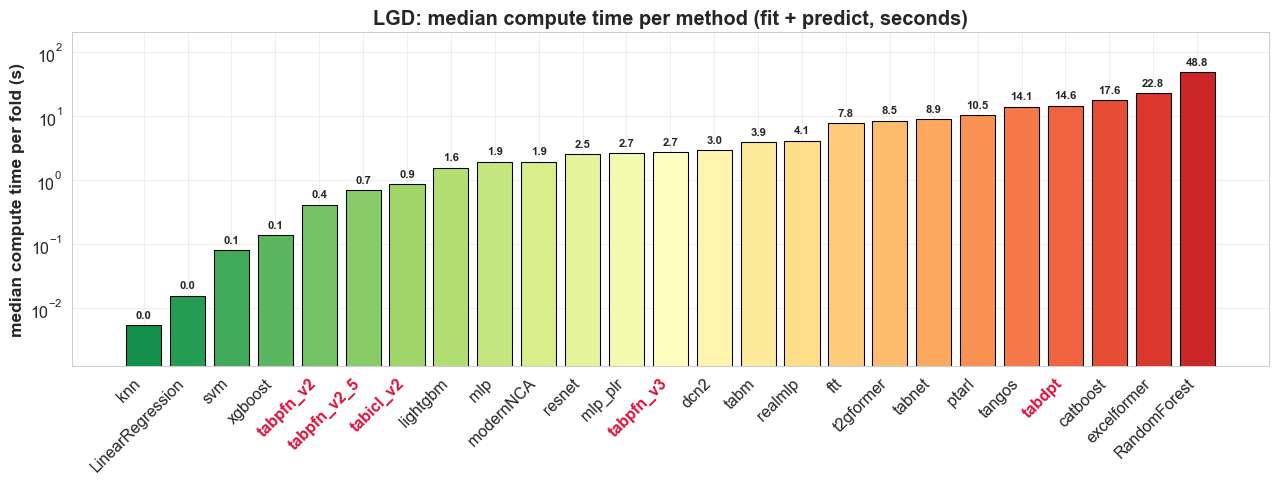

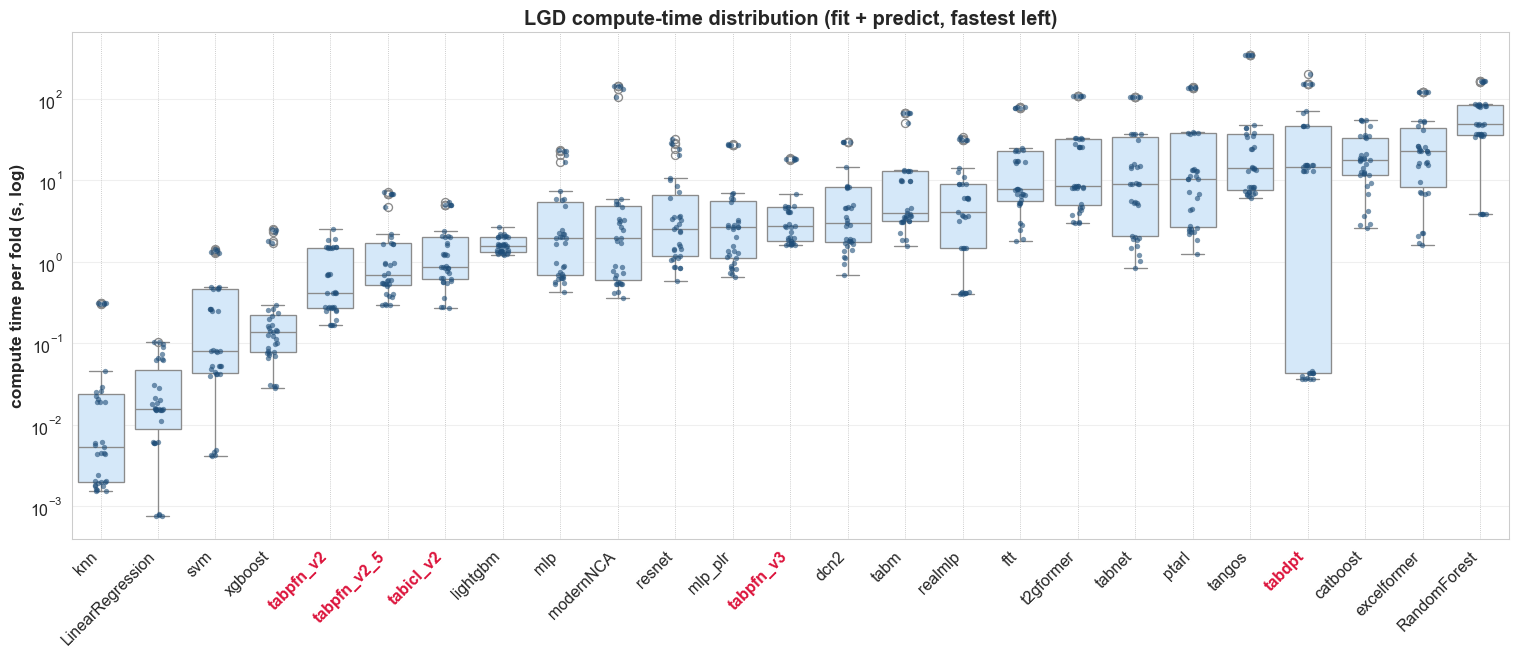

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_compute_time.pdf')

In [5]:
compute_time_bars(df, task_name='LGD', out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='LGD', out_dir=FIGURES_DIR)

## Rank by R² (1 = best on that dataset)

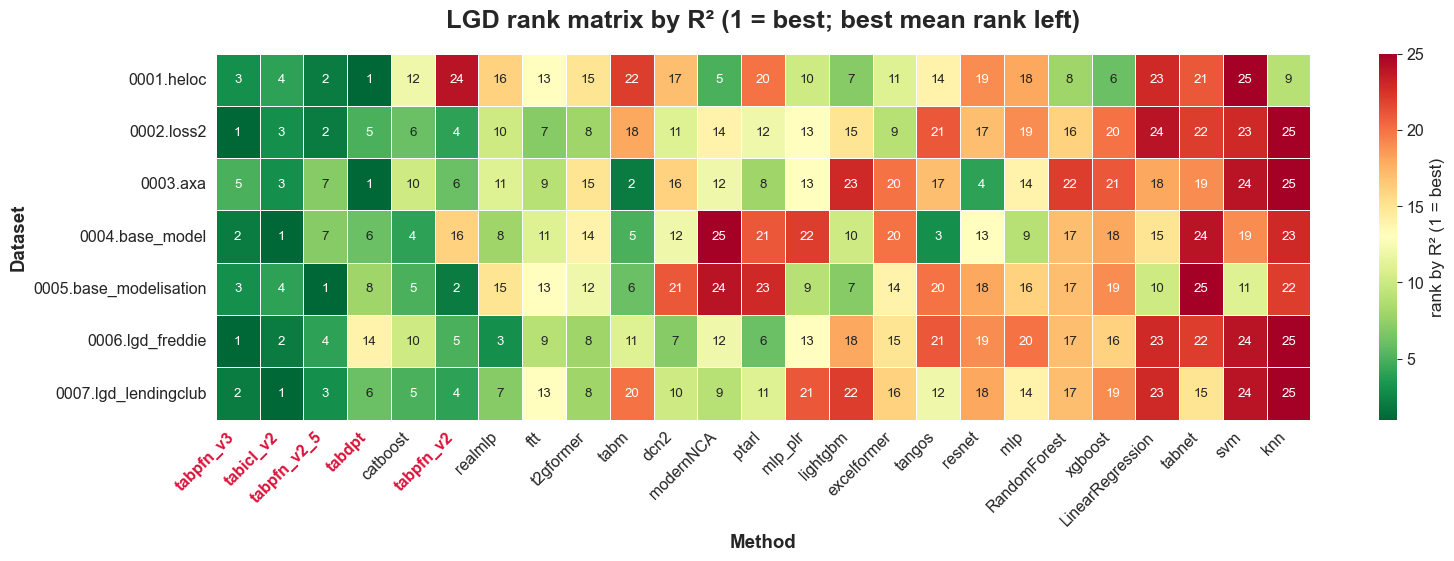

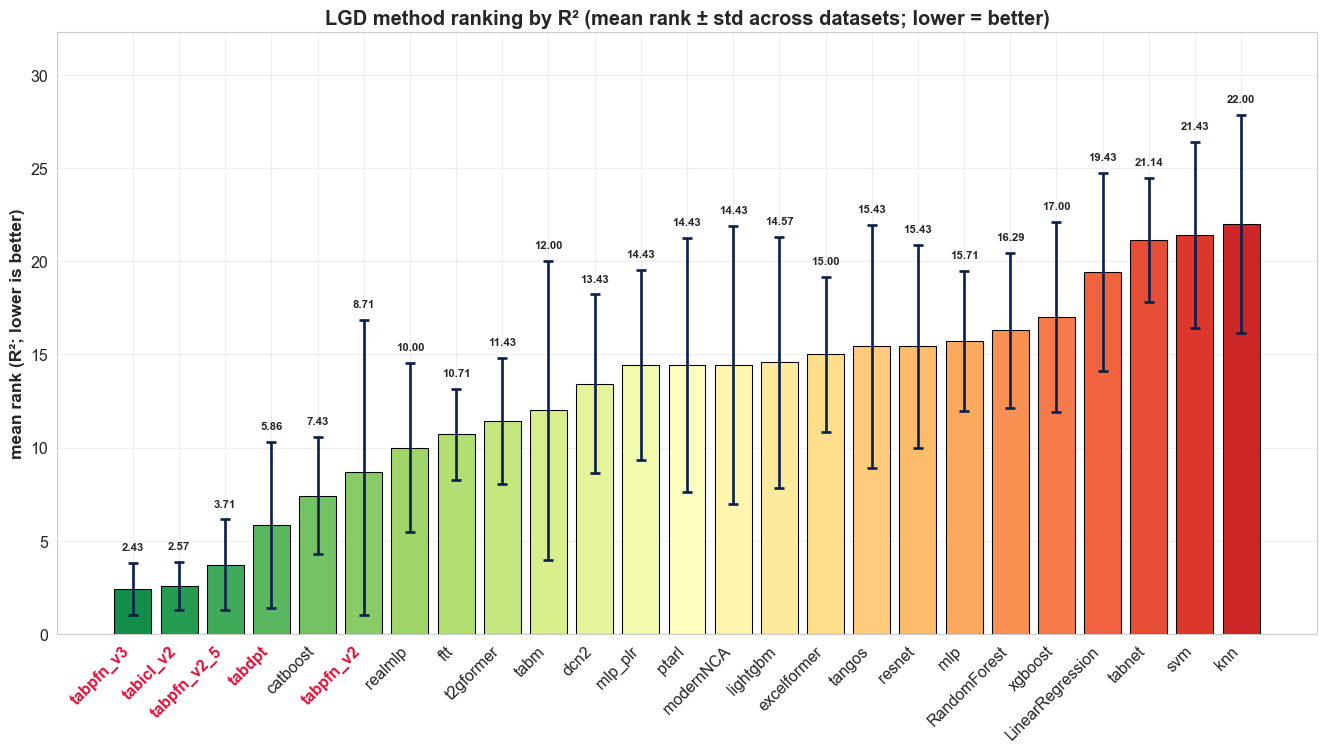

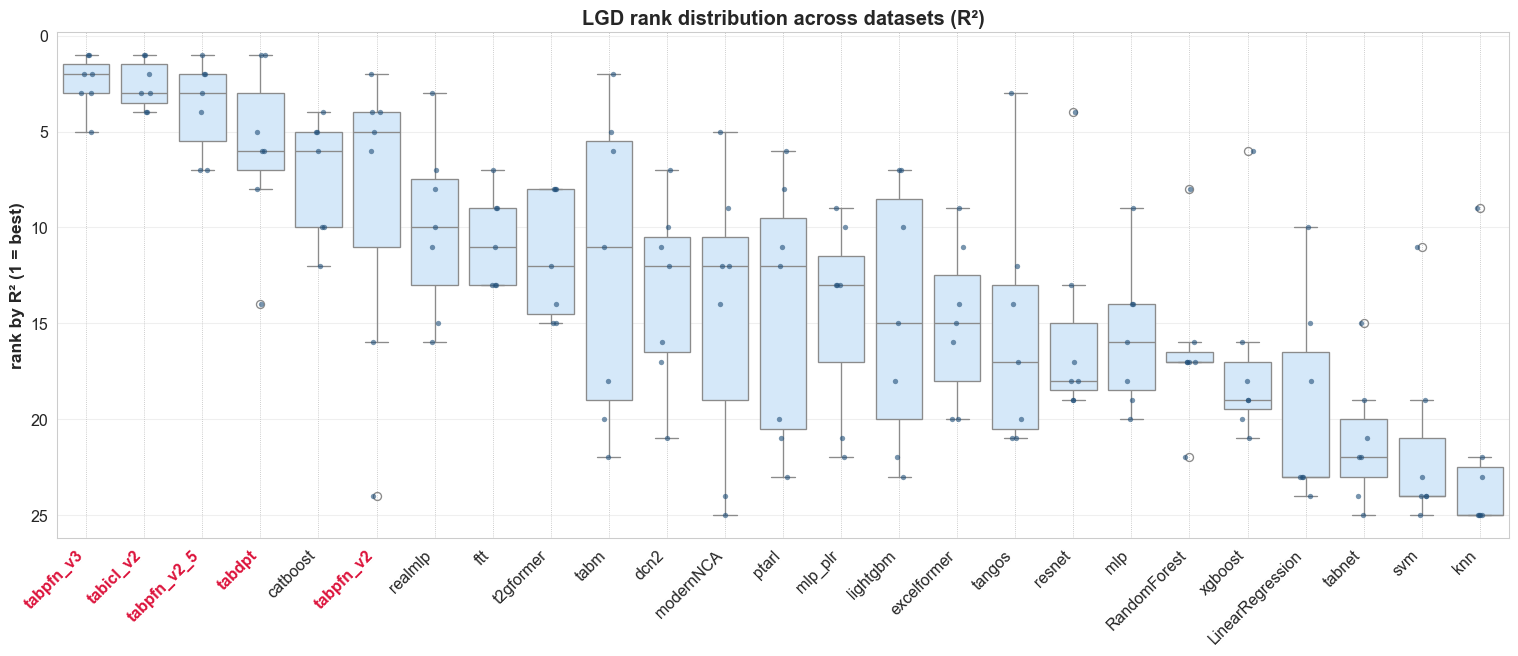

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_rank_box_r2.pdf')

In [6]:
rank_heatmap(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## Effect of HPO on R²

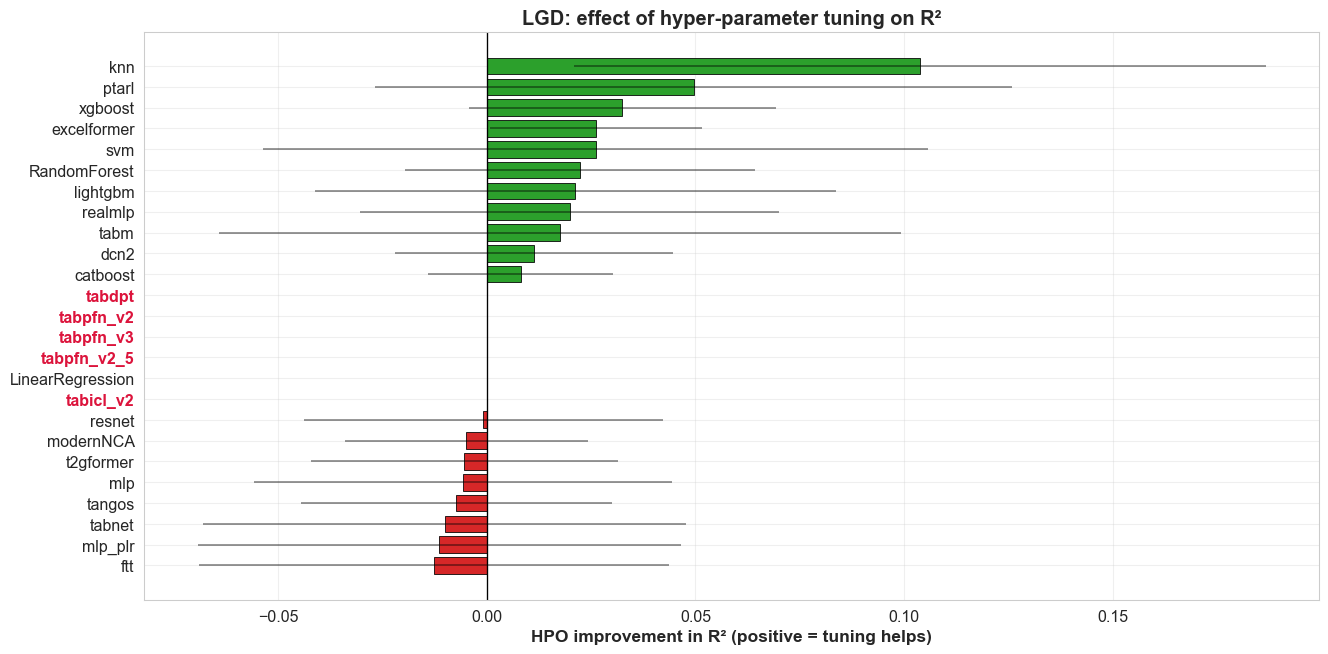

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_hpo_effect_r2.pdf')

In [7]:
hpo_improvement_bars(df_both, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## Performance vs compute time

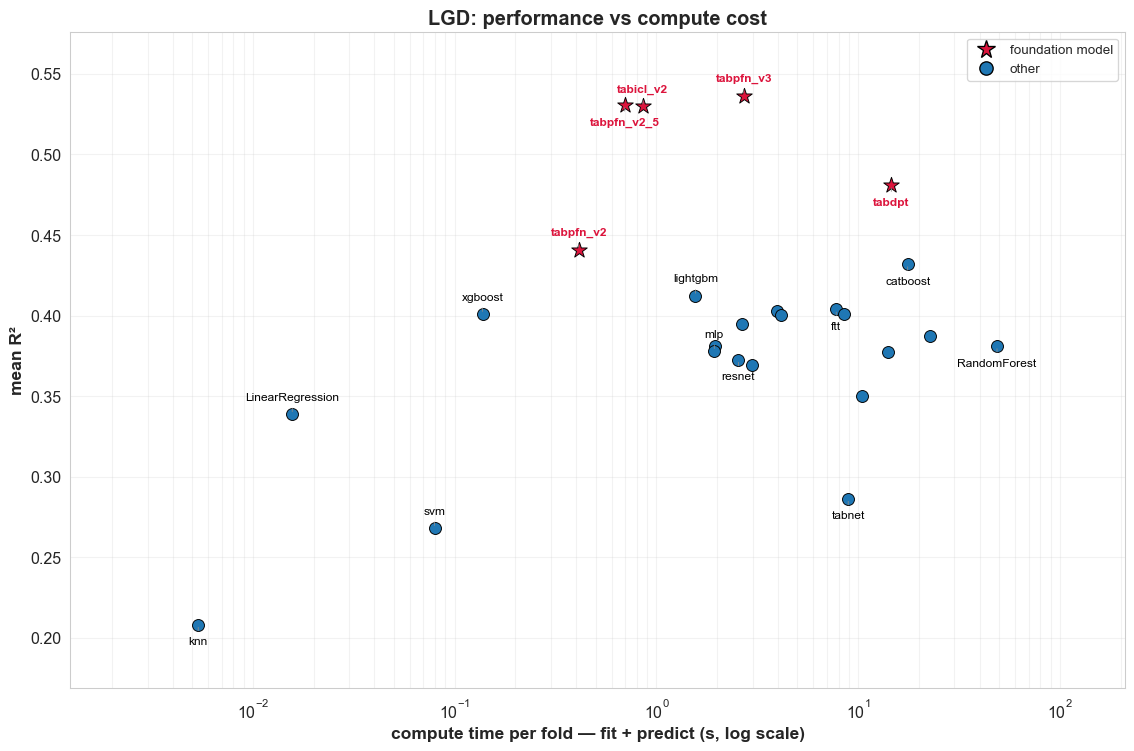

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_cost_quality_r2.pdf')

In [8]:
runtime_performance_scatter(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)

## Summary

In [9]:
lgd_summary_text(df, task_name='Experiment 1 — LGD')

Experiment 1 — LGD — mean of every metric per method   (datasets: 7, methods: 25)
                      R²    RMSE     MAE  Spearman_Corr  Pearson_Corr     MSE   MedAE  MaxError  Explained_Variance        MAPE  MAPE_n_zeros_excluded  MAPE_pct_zeros_excluded  time_s (median)
method                                                                                                                                                                                          
tabpfn_v3         0.5366  0.2234  0.1551         0.6686        0.7139  0.0555  0.1022    0.8898              0.5393  57100.7838               426.1714                  10.0321           2.7098
tabpfn_v2_5       0.5307  0.2235  0.1533         0.6619        0.7071  0.0560  0.0991    0.8906              0.5357  56463.0109               426.1714                  10.0321           0.6962
tabicl_v2         0.5298  0.2263  0.1608         0.6632        0.7088  0.0565  0.1108    0.8862              0.5318  63627.2310               426.

'Experiment 1 — LGD — mean of every metric per method   (datasets: 7, methods: 25)\n=================================================================================\n                      R²    RMSE     MAE  Spearman_Corr  Pearson_Corr     MSE   MedAE  MaxError  Explained_Variance        MAPE  MAPE_n_zeros_excluded  MAPE_pct_zeros_excluded  time_s (median)\nmethod                                                                                                                                                                                          \ntabpfn_v3         0.5366  0.2234  0.1551         0.6686        0.7139  0.0555  0.1022    0.8898              0.5393  57100.7838               426.1714                  10.0321           2.7098\ntabpfn_v2_5       0.5307  0.2235  0.1533         0.6619        0.7071  0.0560  0.0991    0.8906              0.5357  56463.0109               426.1714                  10.0321           0.6962\ntabicl_v2         0.5298  0.2263  0.1608         0.6632  